In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import shap

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 1. Load Data

In [30]:
data = pd.read_csv("./data/Bank Customer Churn Prediction.csv")

print(f"data shape : {data.shape}")
print(f"kolom : {list(data.columns)}")
data.head()

data shape : (10000, 12)
kolom : ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


## 2. Exploratory Data Analysis (EDA) 

### Missing Value & Duplicate

In [32]:
print(f"Missing Value : \n{data.isnull().sum()}")

print(f"\nDuplicate Value : {data.duplicated().sum()}")
print(f"Duplicate customer_id : {data["customer_id"].duplicated().sum()}")

Missing Value : 
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate Value : 0
Duplicate customer_id : 0


### Statistics desc

In [33]:
num_cols = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

cat_cols = [
    "country",
    "gender",
    "credit_card",
    "active_member"
]

data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
products_number,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
estimated_salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


### Target Distribution

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

imbalance ratio (non-churn : churn) = 3.91 : 1


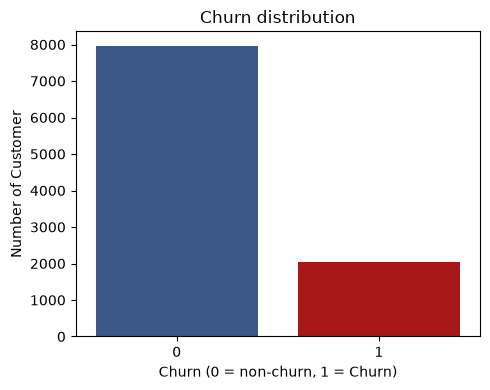

In [34]:
target_dist = data["churn"].value_counts(normalize=True)
print(target_dist)

imbalance_ratio = (data["churn"] == 0).sum() / max((data["churn"] == 1).sum(), 1)
print(f"\nimbalance ratio (non-churn : churn) = {imbalance_ratio:.2f} : 1")

plt.figure(figsize=(5, 4))
sns.countplot(data=data, x="churn", palette=["#2F5496", "#C00000"])

plt.title("Churn distribution")
plt.xlabel("Churn (0 = non-churn, 1 = Churn)")
plt.ylabel("Number of Customer")

plt.tight_layout()
plt.show()

### Numeric fiture distribution

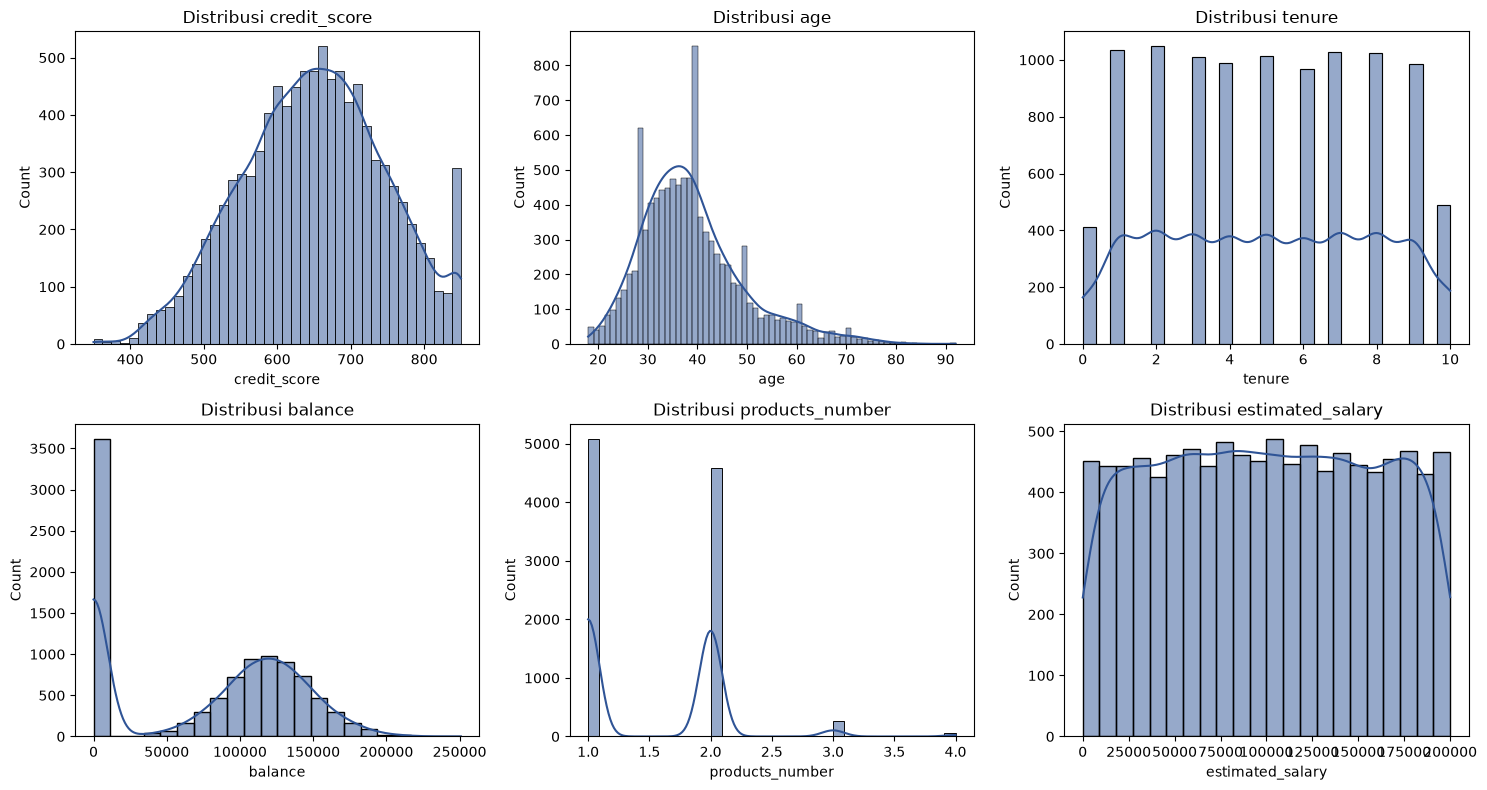

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data[col], kde=True, ax=ax, color="#2F5496")
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

### Numeric vs Target (boxplot)

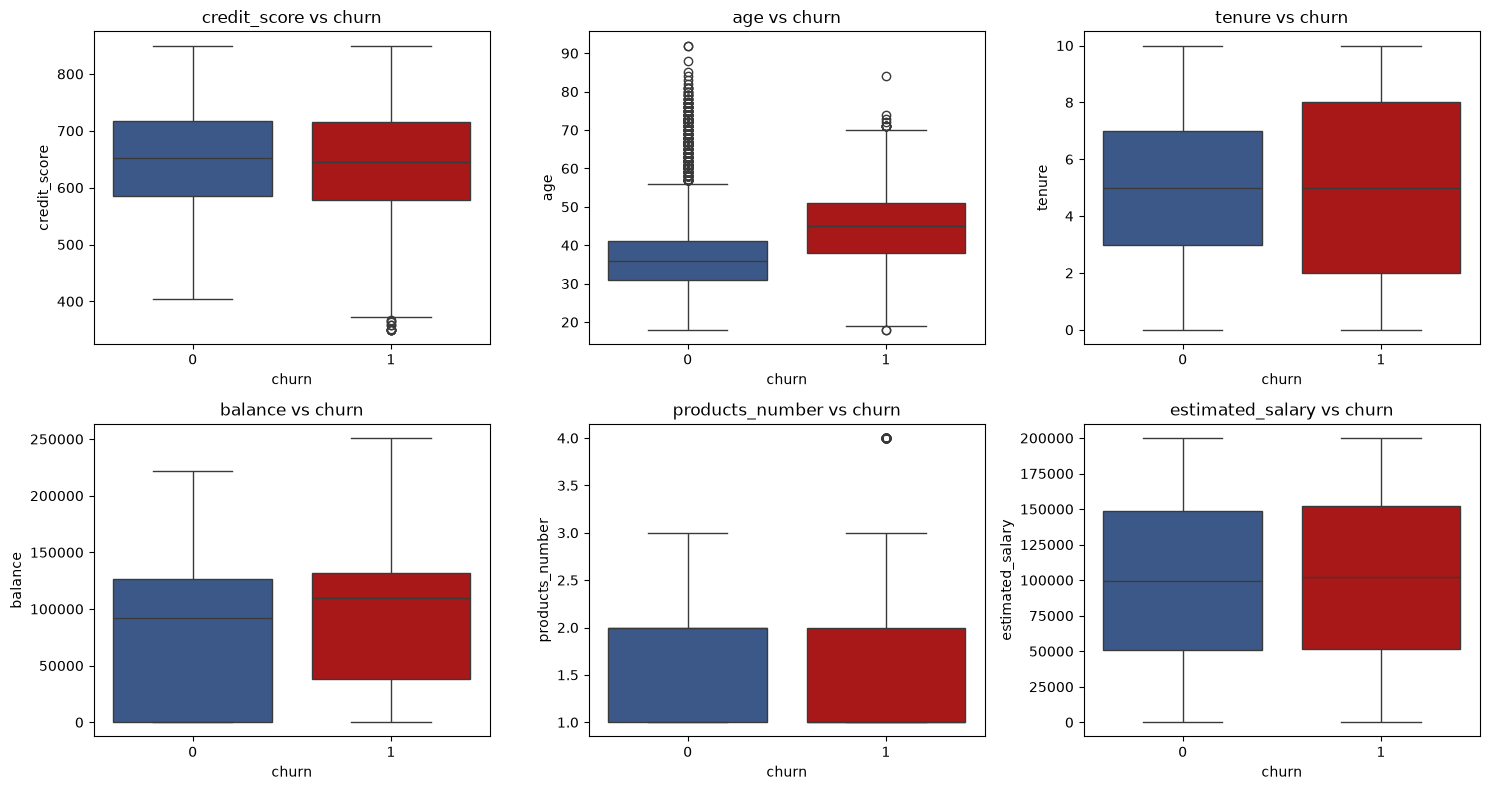

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=data, x="churn", y=col, ax=ax, palette=["#2F5496", "#C00000"])
    ax.set_title(f"{col} vs churn")
plt.tight_layout()
plt.show()

### Churn Rate Per Category

In [37]:
for col in ["country", "gender", "active_member", "products_number", "credit_card"]:
    print(f"\n--- Churn rate per {col} ---")
    print(data.groupby(col)["churn"].mean().round(3))


--- Churn rate per country ---
country
France     0.162
Germany    0.324
Spain      0.167
Name: churn, dtype: float64

--- Churn rate per gender ---
gender
Female    0.251
Male      0.165
Name: churn, dtype: float64

--- Churn rate per active_member ---
active_member
0    0.269
1    0.143
Name: churn, dtype: float64

--- Churn rate per products_number ---
products_number
1    0.277
2    0.076
3    0.827
4    1.000
Name: churn, dtype: float64

--- Churn rate per credit_card ---
credit_card
0    0.208
1    0.202
Name: churn, dtype: float64


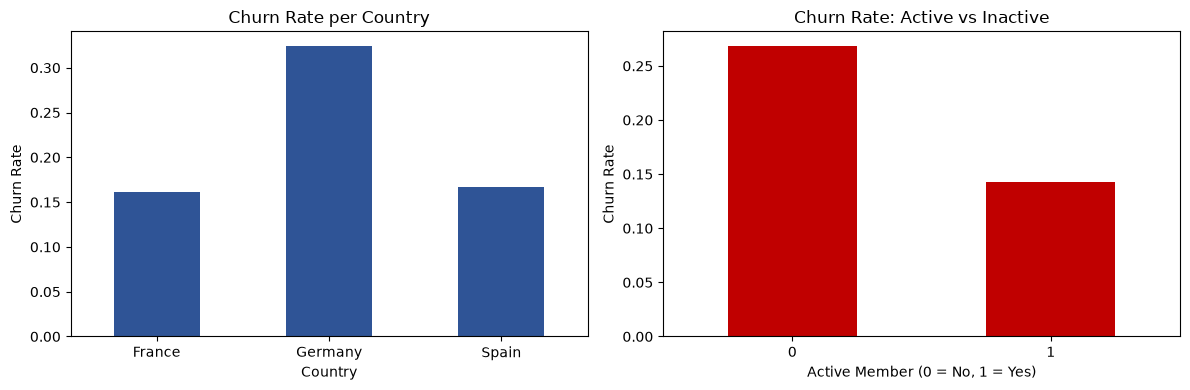

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data.groupby("country")["churn"].mean().plot(
    kind="bar",
    ax=axes[0],
    color="#2F5496"
)
axes[0].set_title("Churn Rate per Country")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis="x", rotation=0)

data.groupby("active_member")["churn"].mean().plot(
    kind="bar",
    ax=axes[1],
    color="#C00000"
)
axes[1].set_title("Churn Rate: Active vs Inactive")
axes[1].set_xlabel("Active Member (0 = No, 1 = Yes)")
axes[1].set_ylabel("Churn Rate")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Correlationa Matrix

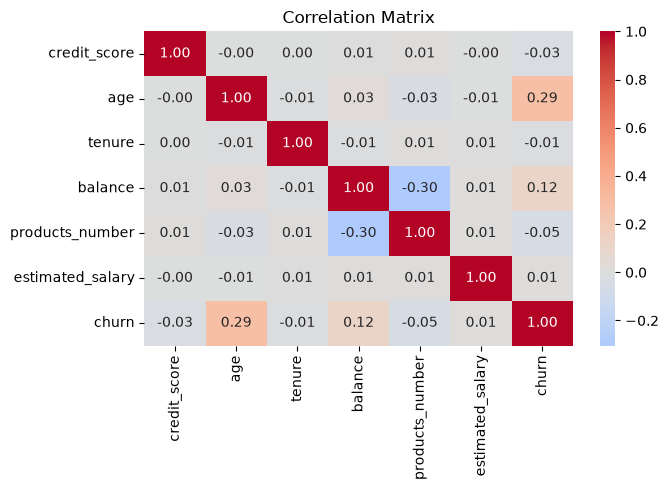

In [39]:
plt.figure(figsize=(7, 5))
corr = data[num_cols + ["churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Outlier Detection (IQR Method)

Outliers shouldn't be automatically discarded—for churn cases, extreme values (such as very advanced age) are often informative rather than noise. This step is simply to identify their presence.

In [40]:
for col in num_cols:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    print(f"{col:18s}: {n_out} outlier (threshold: {lower:.1f} - {upper:.1f})")

credit_score      : 15 outlier (threshold: 383.0 - 919.0)
age               : 359 outlier (threshold: 14.0 - 62.0)
tenure            : 0 outlier (threshold: -3.0 - 13.0)
balance           : 0 outlier (threshold: -191466.4 - 319110.6)
products_number   : 60 outlier (threshold: -0.5 - 3.5)
estimated_salary  : 0 outlier (threshold: -96577.1 - 296967.5)


## Data Cleaning

**Objective**: Fix incorrect data types and drop uninformative columns to improve model generalization.

`id`, `CustomerId`, `Surname` → Unique identifiers with no predictive power; dropped.

- `HasCrCard`, `IsActiveMember` → Binary representations stored as `float64`; converted to `int`.

In [41]:
df_clean = data.copy()

# Hapus kolom identifier
drop_cols = ["customer_id"]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
print(f"Kolom identifier di-drop: {drop_cols}")

# Pastikan kolom biner bertipe integer
df_clean["credit_card"] = df_clean["credit_card"].astype(int)
df_clean["active_member"] = df_clean["active_member"].astype(int)

print("Tipe data credit_card & active_member dikonversi ke int.")

print(f"\nShape setelah cleaning: {df_clean.shape}")
df_clean.head()

Kolom identifier di-drop: ['customer_id']
Tipe data credit_card & active_member dikonversi ke int.

Shape setelah cleaning: (10000, 11)


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Feature Engineering

**Objective:** construct domain-driven derived features based on banking expertise to capture non-linear patterns and feature interactions—signals that linear models cannot capture automatically.

| New Feature | Formula | Rationale |
|---|---|---|
| `ZeroBalanceFlag` | `Balance == 0` | Zero balance is frequently a strong churn signal |
| `BalanceSalaryRatio` | `Balance / EstimatedSalary` | Proportion of wealth relative to income |
| `TenureAgeRatio` | `Tenure / Age` | Proxy for relative loyalty against age |
| `ProductsPerTenure` | `NumOfProducts / (Tenure+1)` | Product adoption velocity |
| `AgeGroup` | Age binning | Captures non-linear relationships between age and churn |
| `CreditScoreCategory` | Credit score binning (industry standard) | Standardized interpretation of credit risk |
| `EngagementSegment` | Interaction of `IsActiveMember` x `NumOfProducts` | Captures the combined effect of activity level and product count |

In [42]:
df_fe = df_clean.copy()

# Numerical features
df_fe["ZeroBalanceFlag"] = (df_fe["balance"] == 0).astype(int)
df_fe["BalanceSalaryRatio"] = df_fe["balance"] / df_fe["estimated_salary"]
df_fe["TenureAgeRatio"] = df_fe["tenure"] / df_fe["age"]
df_fe["ProductsPerTenure"] = df_fe["products_number"] / (df_fe["tenure"] + 1)

df_fe["AgeGroup"] = pd.cut(
    df_fe["age"],
    bins=[0, 30, 45, 60, 120],
    labels=["18-30", "31-45", "46-60", "60+"]
)

df_fe["CreditScoreCategory"] = pd.cut(
    df_fe["credit_score"],
    bins=[0, 579, 669, 739, 799, 900],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)

df_fe["EngagementSegment"] = np.select(
    [
        (df_fe["active_member"] == 1) & (df_fe["products_number"] >= 2),
        (df_fe["active_member"] == 1) & (df_fe["products_number"] == 1),
        (df_fe["active_member"] == 0) & (df_fe["products_number"] >= 2),
    ],
    [
        "Active-Multi Product",
        "Active-Single Product",
        "Inactive-Multi Product",
    ],
    default="Inactive-Single Product"
)

print(f"\nShape after feature engineering: {df_fe.shape}")

df_fe.to_csv("./data/cleaned_engineered_churn.csv", index=False)

df_fe.head()


Shape after feature engineering: (10000, 18)


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,ZeroBalanceFlag,BalanceSalaryRatio,TenureAgeRatio,ProductsPerTenure,AgeGroup,CreditScoreCategory,EngagementSegment
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,0.000000,0.047619,0.333333,31-45,Fair,Active-Single Product
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,0.744677,0.024390,0.500000,31-45,Fair,Active-Single Product
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,1.401375,0.190476,0.333333,31-45,Poor,Inactive-Multi Product
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1,0.000000,0.025641,1.000000,31-45,Good,Inactive-Multi Product
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,1.587055,0.046512,0.333333,31-45,Excellent,Active-Single Product


### Quick Validation: Churn Rate per New Feature

In [43]:
for col in ["AgeGroup", "CreditScoreCategory", "EngagementSegment", "ZeroBalanceFlag"]:
    print(f"\n--- Churn rate per {col} ---")
    print(df_fe.groupby(col, observed=True)["churn"].mean().round(3))


--- Churn rate per AgeGroup ---
AgeGroup
18-30    0.075
31-45    0.157
46-60    0.511
60+      0.248
Name: churn, dtype: float64

--- Churn rate per CreditScoreCategory ---
CreditScoreCategory
Poor         0.220
Fair         0.206
Good         0.186
Very Good    0.206
Excellent    0.195
Name: churn, dtype: float64

--- Churn rate per EngagementSegment ---
EngagementSegment
Active-Multi Product       0.097
Active-Single Product      0.189
Inactive-Multi Product     0.162
Inactive-Single Product    0.367
Name: churn, dtype: float64

--- Churn rate per ZeroBalanceFlag ---
ZeroBalanceFlag
0    0.241
1    0.138
Name: churn, dtype: float64


## Train-Test Split

In [44]:
X = df_fe.drop(columns=["churn"])
y = df_fe["churn"]

for c in ["AgeGroup", "CreditScoreCategory"]:
    X[c] = X[c].astype(str)

numeric_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary",
    "BalanceSalaryRatio",
    "TenureAgeRatio",
    "ProductsPerTenure"
]

categorical_features = [
    "country",
    "gender",
    "credit_card",
    "active_member",
    "ZeroBalanceFlag",
    "AgeGroup",
    "CreditScoreCategory",
    "EngagementSegment"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Proporsi churn di train: {y_train.mean():.3f} | di test: {y_test.mean():.3f}")

Train shape: (8000, 17), Test shape: (2000, 17)
Proporsi churn di train: 0.204 | di test: 0.203


## Processing Pipeline

In [45]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

## Imbalace Class Handling

In [46]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_cw = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                random_state=RANDOM_STATE)),
])

pipe_smote = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

f1_cw = cross_val_score(pipe_cw, X_train, y_train, cv=cv, scoring="f1").mean()
f1_smote = cross_val_score(pipe_smote, X_train, y_train, cv=cv, scoring="f1").mean()

print(f"F1-score (class_weight='balanced', CV 5-fold): {f1_cw:.3f}")
print(f"F1-score (SMOTE, CV 5-fold)                  : {f1_smote:.3f}")

USE_SMOTE = f1_smote > f1_cw
print(f"\n-> choosed strategy: {'SMOTE' if USE_SMOTE else "class_weight='balanced'"}")

F1-score (class_weight='balanced', CV 5-fold): 0.577
F1-score (SMOTE, CV 5-fold)                  : 0.579

-> choosed strategy: SMOTE


## Model Compare

In [47]:
def make_pipeline(model, use_smote):
    steps = [("prep", preprocessor)]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)))
        PipelineClass = ImbPipeline
    else:
        PipelineClass = Pipeline
    steps.append(("clf", model))
    return PipelineClass(steps)

models = {
    "Logistic Regression (baseline)": LogisticRegression(
        max_iter=1000, class_weight=None if USE_SMOTE else "balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight=None if USE_SMOTE else "balanced",
        random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.08,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(1 if USE_SMOTE else (y_train == 0).sum() / (y_train == 1).sum())
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.08,
        class_weight=None if USE_SMOTE else "balanced",
        random_state=RANDOM_STATE, verbosity=-1
    ),
}

cv_results = {}
for name, model in models.items():
    pipe = make_pipeline(model, USE_SMOTE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:32s} | ROC-AUC CV: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\n-> Model dengan ROC-AUC CV tertinggi: {best_model_name}")

Logistic Regression (baseline)   | ROC-AUC CV: 0.841 (+/- 0.013)
Random Forest                    | ROC-AUC CV: 0.845 (+/- 0.015)
XGBoost                          | ROC-AUC CV: 0.854 (+/- 0.013)
LightGBM                         | ROC-AUC CV: 0.857 (+/- 0.014)

-> Model dengan ROC-AUC CV tertinggi: LightGBM


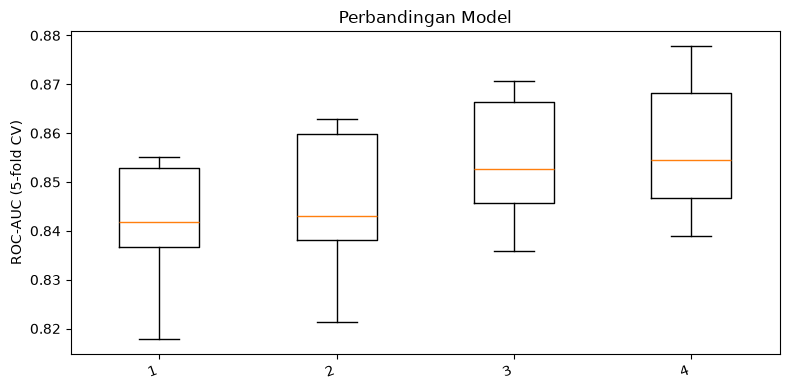

In [48]:
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results.values(), label=cv_results.keys())
plt.xticks(rotation=20, ha="right")
plt.ylabel("ROC-AUC (5-fold CV)")
plt.title("Perbandingan Model")
plt.tight_layout()
plt.show()

## Hyperparamenter Tuning

**Objective:** find the best hyperparameter combination for the model with the highest cross-validation performance from the previous step, using `RandomizedSearchCV` (more efficient than full Grid Search for large parameter spaces).

In [49]:
if best_model_name == "Random Forest":
    param_dist = {
        "clf__n_estimators": [100, 200, 300, 400],
        "clf__max_depth": [3, 5, 7, None],
        "clf__min_samples_leaf": [1, 2, 4],
    }
    base_model = RandomForestClassifier(
        class_weight=None if USE_SMOTE else "balanced", random_state=RANDOM_STATE
    )
elif best_model_name == "XGBoost":
    param_dist = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 4, 5, 6],
        "clf__learning_rate": [0.03, 0.05, 0.08, 0.1],
    }
    base_model = xgb.XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(1 if USE_SMOTE else (y_train == 0).sum() / (y_train == 1).sum())
    )
elif best_model_name == "LightGBM":
    param_dist = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 4, 5, -1],
        "clf__learning_rate": [0.03, 0.05, 0.08, 0.1],
    }
    base_model = lgb.LGBMClassifier(
        class_weight=None if USE_SMOTE else "balanced",
        random_state=RANDOM_STATE, verbosity=-1
    )
else:
    param_dist = {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
    }
    base_model = LogisticRegression(
        max_iter=1000, class_weight=None if USE_SMOTE else "balanced",
        random_state=RANDOM_STATE
    )

final_pipe = make_pipeline(base_model, USE_SMOTE)

search = RandomizedSearchCV(
    final_pipe, param_distributions=param_dist, n_iter=12, cv=cv,
    scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)

print(f"Best params     : {search.best_params_}")
print(f"Best CV ROC-AUC : {search.best_score_:.3f}")

best_pipe = search.best_estimator_

Best params     : {'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.03}
Best CV ROC-AUC : 0.857


## Model Evaluation on Test set

**Objective:** measure the final model's performance on data that has **never been seen** during training or tuning—this provides the most honest estimate of real-world performance.

Metrics used (going beyond accuracy due to class imbalance):
- **Precision, Recall, F1-score**
- **ROC-AUC** — ability of the model to discriminate between classes
- **PR-AUC (Average Precision)** — more informative for imbalanced datasets

In [50]:
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=3))

print(f"ROC-AUC (test)        : {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC / Avg Precision: {average_precision_score(y_test, y_proba):.3f}")
print(f"F1-score (test)       : {f1_score(y_test, y_pred):.3f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0      0.902     0.923     0.913      1593
           1      0.670     0.609     0.638       407

    accuracy                          0.860      2000
   macro avg      0.786     0.766     0.776      2000
weighted avg      0.855     0.860     0.857      2000

ROC-AUC (test)        : 0.871
PR-AUC / Avg Precision: 0.718
F1-score (test)       : 0.638


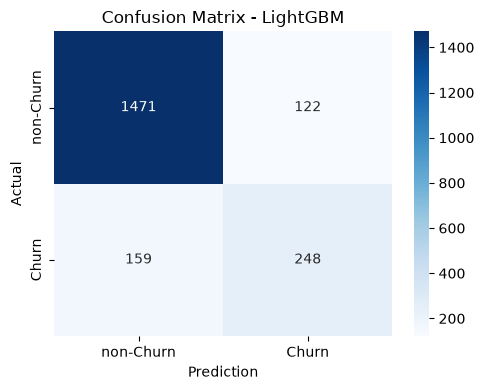

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-Churn", "Churn"], yticklabels=["non-Churn", "Churn"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Prediction")
plt.tight_layout()
plt.show()

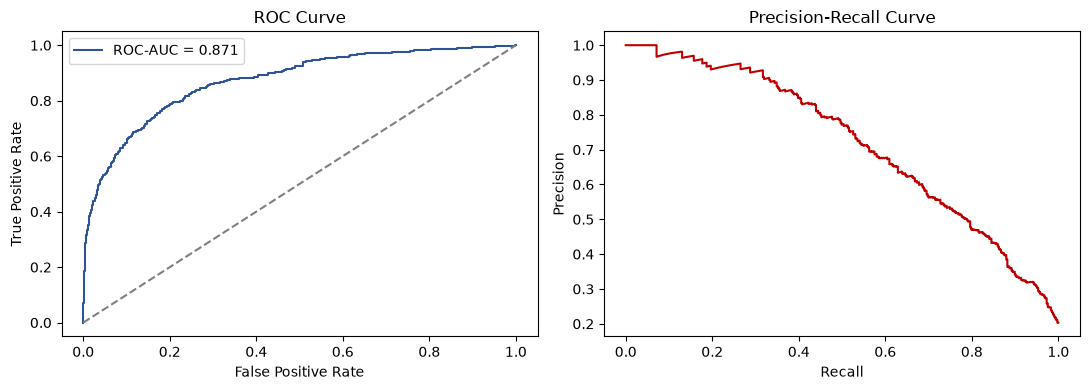

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}", color="#2F5496")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color="#C00000")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## Interpretability

**Objective:** explain **why** the model makes specific predictions—crucial for business team trust and regulatory compliance (especially in the banking industry).

- **Global interpretability:** identifying which features are the most influential overall.
- **Local interpretability:** explaining the direction of each feature's impact on an individual prediction (e.g., red pushes toward churn, blue pushes toward non-churn).

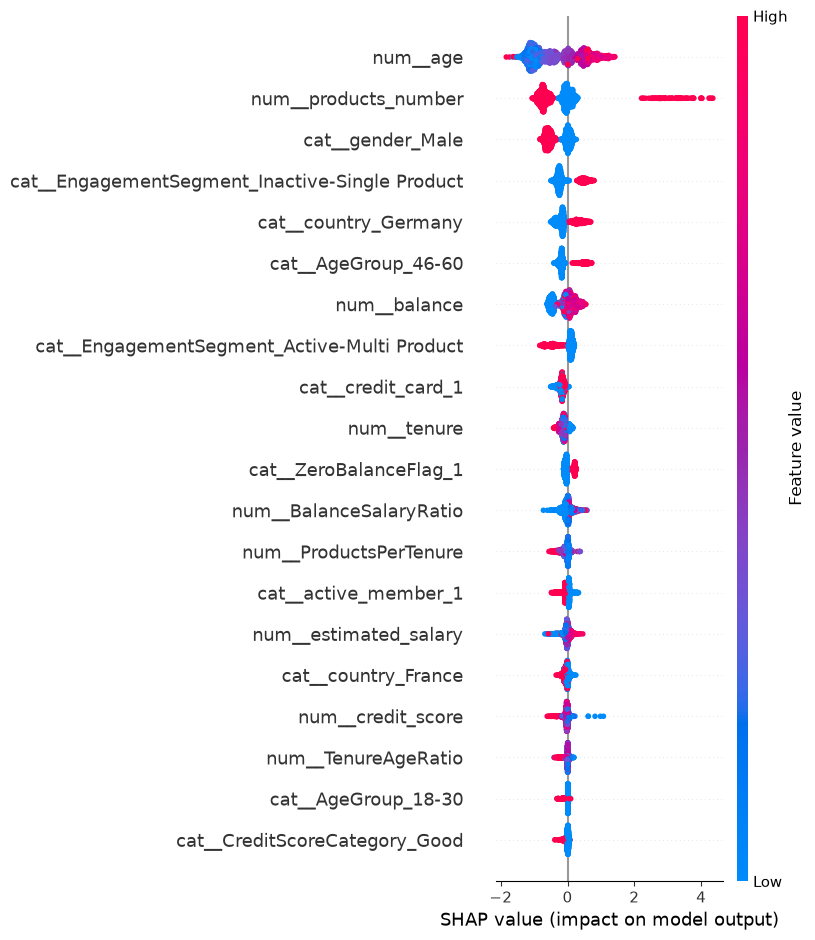

In [53]:
X_test_transformed = best_pipe.named_steps["prep"].transform(X_test)
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
clf_model = best_pipe.named_steps["clf"]

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

if best_model_name in ("Random Forest", "XGBoost", "LightGBM"):
    explainer = shap.TreeExplainer(clf_model)
    shap_values = explainer.shap_values(X_test_df)
    shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    explainer = shap.LinearExplainer(clf_model, X_test_df)
    shap_values_plot = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values_plot, X_test_df, show=True)

## How to Read This Chart (SHAP Summary Plot)

This chart explains how the machine learning model decides whether a customer will churn. 

### **1. Top to Bottom: Most Important Factors**
* Features are ranked from top to bottom by importance. 
* **`num__age`** at the very top is the biggest driving factor in predicting customer churn, while features near the bottom have very little impact.

### **2. Left to Right: Direction of Impact**
* **Right side (Positive SHAP values):** Pushes the customer **toward churning** (leaving the bank).
* **Left side (Negative SHAP values):** Pushes the customer **toward staying** with the bank.

### **3. Colors: High vs. Low Values**
* **Red (High):** Represents a high value for that feature (e.g., older age, high number of products).
* **Blue (Low):** Represents a low value for that feature (e.g., younger age, low number of products).

---

### **Key Takeaways from the Data:**
* **Age (`num__age`):** Older customers tend to show up more on the right side, meaning age plays a critical role in predicting who leaves.
* **Products (`num__products_number`):** Notice the bright red dots clustered heavily to the far right—having a specific number of products strongly increases the likelihood of churn.